In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
df=pd.read_csv("C:/Internships/projects/WeatherLens India/clean_weather.csv")
df.head()

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,rain_sum,wind_speed_10m_max,rain_tomorrow,weather_condition,year,month,day,season,temp_range,weather_cluster,weather_pattern
0,Delhi,01-01-2000,19.9,7.4,19.2,5.8,0.0,10.9,0,Clear,2000,1,1,Winter,12.5,0,Cold Winter
1,Delhi,02-01-2000,20.0,5.5,18.9,3.4,0.0,9.5,0,Overcast,2000,1,2,Winter,14.5,0,Cold Winter
2,Delhi,03-01-2000,20.1,6.3,18.2,4.3,0.0,10.0,0,Clear,2000,1,3,Winter,13.8,0,Cold Winter
3,Delhi,04-01-2000,19.8,6.4,18.5,4.2,0.0,8.6,0,Clear,2000,1,4,Winter,13.4,0,Cold Winter
4,Delhi,05-01-2000,19.4,5.3,17.7,3.2,0.0,9.4,0,Clear,2000,1,5,Winter,14.1,0,Cold Winter


In [3]:
print(df.columns.tolist())

['city', 'date', 'temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max', 'apparent_temperature_min', 'rain_sum', 'wind_speed_10m_max', 'rain_tomorrow', 'weather_condition', 'year', 'month', 'day', 'season', 'temp_range', 'weather_cluster', 'weather_pattern']


In [4]:


# Features for clustering
cluster_features = ['temperature_2m_max', 'temperature_2m_min',
                    'apparent_temperature_max', 'apparent_temperature_min',
                    'rain_sum', 'wind_speed_10m_max', 'temp_range']

X = df[cluster_features]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['weather_cluster'] = kmeans.fit_predict(X_scaled)

# Add readable names
cluster_names = {0: 'Cold Winter', 1: 'Mild Transition',
                 2: 'Dry Summer', 3: 'Heavy Monsoon'}
df['weather_pattern'] = df['weather_cluster'].map(cluster_names)

# Save updated file
df.to_csv('clean_weather.csv', index=False)
print("✅ Saved with cluster columns!")
print(df.columns.tolist())

✅ Saved with cluster columns!
['city', 'date', 'temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max', 'apparent_temperature_min', 'rain_sum', 'wind_speed_10m_max', 'rain_tomorrow', 'weather_condition', 'year', 'month', 'day', 'season', 'temp_range', 'weather_cluster', 'weather_pattern']


In [5]:
df['weather_pattern'].value_counts()

weather_pattern
Dry Summer         30705
Mild Transition    28164
Heavy Monsoon      19335
Cold Winter        13116
Name: count, dtype: int64

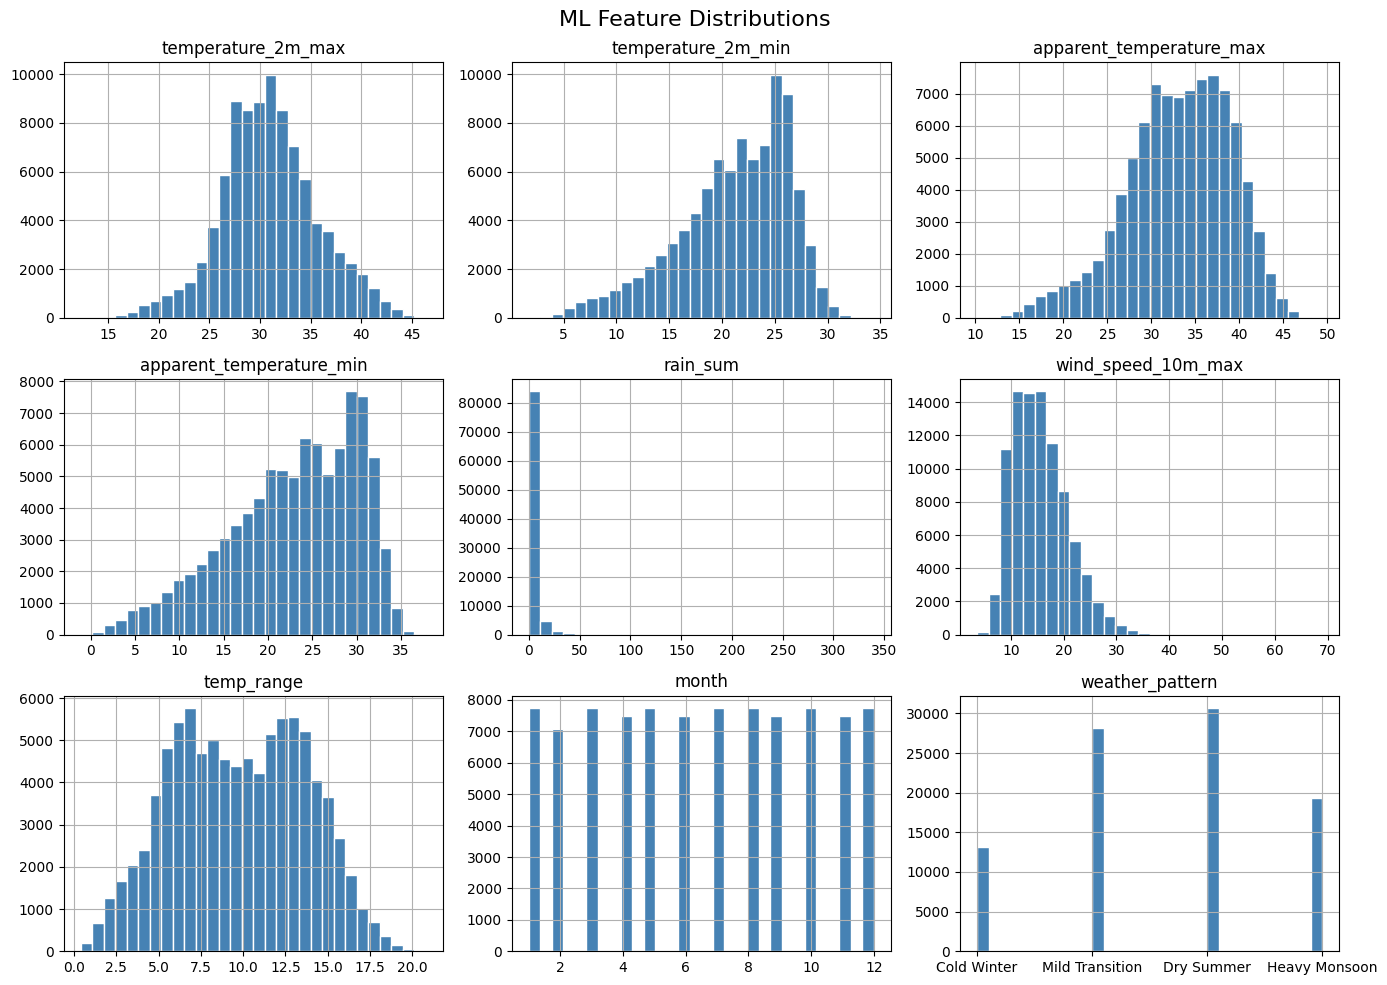

In [6]:
#diatribution of the features
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('ML Feature Distributions', fontsize=16)

features = ['temperature_2m_max', 'temperature_2m_min',
            'apparent_temperature_max', 'apparent_temperature_min',
            'rain_sum', 'wind_speed_10m_max',
            'temp_range', 'month', 'weather_pattern']

for i, feature in enumerate(features):
    ax = axes[i//3, i%3]
    df[feature].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(feature)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### ML Feature Distributions — Observations
Temperature features (temperature_2m_max, temperature_2m_min, apparent_temperature_max, apparent_temperature_min) follow a roughly normal bell shaped distribution, indicating stable and consistent temperature recordings across all 10 cities over 24 years — no transformation needed before modelling.<br>

(rain_sum)is heavily right skewed with most values concentrated near zero — confirming that majority of days record little to no rainfall.<br>

(wind_speed_10m_max) is right skewed with most days recording low to moderate wind speeds and few extreme wind days — consistent with normal Indian weather behaviour.<br>

(temp_range) shows a bimodal pattern with two peaks — one representing monsoon days (small temp gap due to cloud cover) and one representing dry summer and winter days (large temp gap due to clear skies). This dual pattern confirms why temp range was our strongest predictor at -0.67 correlation.<br>

(month) shows perfectly uniform distribution — confirming equal representation of all 12 months across the dataset with no seasonal bias in data collection.<br>

(weather_pattern) shows Dry Summer dominating with 30,705 days followed by Mild Transition, Heavy Monsoon and Cold Winter — exactly matching our K-Means clustering findings and reflecting real Indian climate proportions.

In [10]:
#Random Forest model
X=X = df[['temperature_2m_max', 'temperature_2m_min',
        'apparent_temperature_max', 'apparent_temperature_min',
        'rain_sum', 'wind_speed_10m_max', 
        'temp_range', 'month', 'weather_cluster']]

y= df['rain_tomorrow']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print('Target Distributions:\n', y.value_counts())

Features (X) shape: (91320, 9)
Target (y) shape: (91320,)
Target Distributions:
 rain_tomorrow
0    53317
1    38003
Name: count, dtype: int64


In [11]:
print(X.dtypes)

temperature_2m_max          float64
temperature_2m_min          float64
apparent_temperature_max    float64
apparent_temperature_min    float64
rain_sum                    float64
wind_speed_10m_max          float64
temp_range                  float64
month                         int64
weather_cluster               int32
dtype: object


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                      random_state=42,
                                                        stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print ('Training Target Distributions:\n', y_train.value_counts())
print ('Testing Target Distributions:\n', y_test.value_counts())

Training set shape: (73056, 9)
Testing set shape: (18264, 9)
Training Target Distributions:
 rain_tomorrow
0    42654
1    30402
Name: count, dtype: int64
Testing Target Distributions:
 rain_tomorrow
0    10663
1     7601
Name: count, dtype: int64


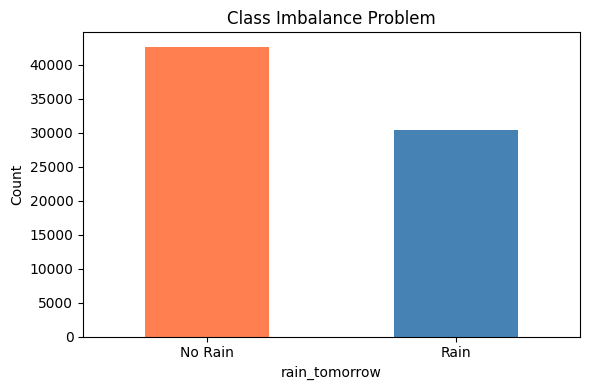

In [13]:
# Show the problem first
plt.figure(figsize=(6, 4))
y_train.value_counts().plot(kind='bar', color=['coral','steelblue'])
plt.title('Class Imbalance Problem')
plt.xticks([0, 1], ['No Rain', 'Rain'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

This imbalance will bias our model toward always 
predicting No Rain. To fix this we apply SMOTE — 
which creates synthetic Rain day examples until 
both classes are balanced.

In [14]:
#Smote
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Before SMOTE:", X_train.shape)
print("After SMOTE:", X_train_smote.shape)
print('After SMOTE Training Target Distributions:\n', y_train_smote.value_counts())


Before SMOTE: (73056, 9)
After SMOTE: (85308, 9)
After SMOTE Training Target Distributions:
 rain_tomorrow
0    42654
1    42654
Name: count, dtype: int64


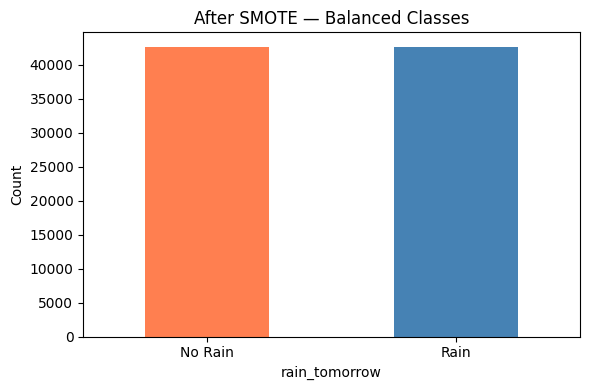

In [15]:
# Show the solution
plt.figure(figsize=(6, 4))
y_train_smote.value_counts().plot(kind='bar', color=['coral','steelblue'])
plt.title('After SMOTE — Balanced Classes')
plt.xticks([0, 1], ['No Rain', 'Rain'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [16]:
from sklearn.ensemble import RandomForestClassifier
import time


In [17]:
start_time = time.time()
# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

end = time.time()
print("Model trained")

Model trained


In [19]:
#prediction
y_predictions = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("First 10 predictions:", y_predictions[:11])
print("First Actual values: ", y_test.values[:11])
print("First 10 predicted probabilities:", y_pred_proba[:11].round(3))



First 10 predictions: [0 0 0 0 1 0 0 1 1 1 0]
First Actual values:  [0 0 0 0 1 0 0 1 1 1 0]
First 10 predicted probabilities: [0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0.]


In [20]:
print(rf_model.feature_importances_)
print("---")
print(X.columns.tolist())

[0.00815545 0.02578912 0.00139682 0.04158298 0.6982148  0.00198277
 0.14318202 0.02114599 0.05855005]
---
['temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max', 'apparent_temperature_min', 'rain_sum', 'wind_speed_10m_max', 'temp_range', 'month', 'weather_cluster']


## Rebuilding the Model — Leak-Free Pipeline

Since `rain_sum` was identified as a leaked feature, the entire 
modelling pipeline is rebuilt from scratch using only genuine 
atmospheric features. This ensures our Random Forest model 
learns real weather patterns to predict rainfall, rather than 
simply reading the answer from a derived column.<br>

The pipeline below repeats feature selection, train-test split, 
SMOTE balancing, and model training — this time using a clean, 
leak-free feature set.## Rebuilding the Model — Leak-Free Pipeline


In [5]:
X = df[['temperature_2m_max', 'temperature_2m_min',
        'apparent_temperature_max', 'apparent_temperature_min',
        'wind_speed_10m_max', 
        'temp_range', 'month', 'weather_cluster']]

y = df['rain_tomorrow']

print("Features shape:", X.shape)

Features shape: (91320, 8)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (73056, 8)
Test set shape: (18264, 8)


In [7]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Before SMOTE:", X_train.shape)
print("After SMOTE:", X_train_smote.shape)

Before SMOTE: (73056, 8)
After SMOTE: (85308, 8)


In [8]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

print("Model trained")

Model trained


In [9]:
#prediction
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Sample predictions:", y_pred[:10])
print("Actual values: ",y_test[:10].values)
print("Sample predicted probabilities:", y_pred_proba[:10].round(2))

print("---")
print("Feature importance:")
for feature, importance in zip(X.columns, rf_model.feature_importances_):
    print(f"{feature}: {importance:.3f}")

Sample predictions: [0 0 1 0 1 1 0 1 1 1]
Actual values:  [0 0 0 0 1 0 0 1 1 1]
Sample predicted probabilities: [0.04 0.13 0.98 0.   0.55 0.82 0.26 0.73 0.56 1.  ]
---
Feature importance:
temperature_2m_max: 0.095
temperature_2m_min: 0.107
apparent_temperature_max: 0.080
apparent_temperature_min: 0.132
wind_speed_10m_max: 0.081
temp_range: 0.293
month: 0.110
weather_cluster: 0.102


In [10]:
#ROC-AUC curve, F1- score, Classification report, confusion matrix
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix

roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print(f"ROC-AUC Score: {roc_auc:.3f}")
print(f"F1 Score: {f1:.3f}")
print("---")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC Score: 0.944
F1 Score: 0.851
---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     10663
           1       0.86      0.85      0.85      7601

    accuracy                           0.88     18264
   macro avg       0.87      0.87      0.87     18264
weighted avg       0.88      0.88      0.88     18264

---
Confusion Matrix:
[[9573 1090]
 [1169 6432]]


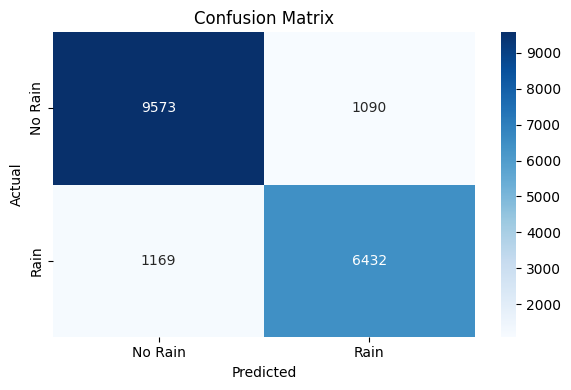

In [11]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

#### Observation:
Out of 18,264 testbr days, the model correctly predicted 9,573 No Rain days and 6,432 Rain days — a combined 15,995 correct predictions out of 18,264 (88% accuracy).<br> The model made 1,090 false alarms (predicted rain when none occurred) and missed 1,169 actual rainy days (predicted no rain when it did rain).<br> The relatively balanced error distribution between both classes confirms that SMOTE successfully prevented the model from being biased toward the majority "No Rain" class.

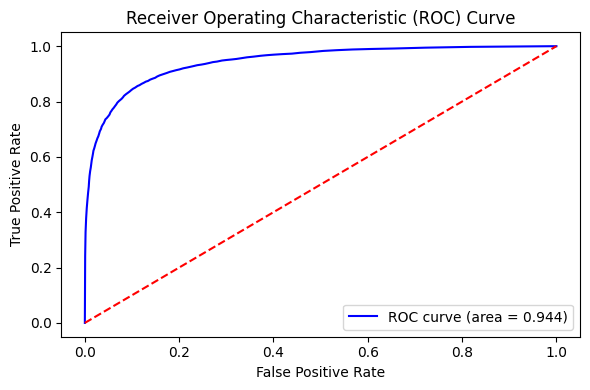

In [14]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


##### Observations:
The ROC curve achieved an AUC of 0.944, indicating the model can distinguish between rainy and non-rainy days with 94.4% effectiveness — substantially outperforming the 50% baseline of random guessing (represented by the red dashed line).<br>The curve rises sharply near the origin and stays close to the top-left corner throughout, confirming the model achieves a high true positive rate while maintaining a low false positive rate.<br> This strong AUC score validates that our feature engineering — particularly temp_range and weather_cluster — successfully captured genuine predictive signals from Indian weather patterns.

In [15]:
#Saving the model
import joblib

In [16]:
joblib.dump(rf_model, 'rainfall_model.pkl')
print("Model saved as rainfall_model.pkl!")

Model saved as rainfall_model.pkl!


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model_optimized = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,        # limits tree depth
    min_samples_leaf=5,  # prevents overly complex trees
    random_state=42,
    n_jobs=-1
)

rf_model_optimized.fit(X_train_smote, y_train_smote)

# Check new file size
import joblib
joblib.dump(rf_model_optimized, 'rainfall_model.pkl')

import os
size_mb = os.path.getsize('rainfall_model.pkl') / (1024*1024)
print(f"New model size: {size_mb:.2f} MB")

New model size: 39.37 MB


In [18]:
y_pred_new = rf_model_optimized.predict(X_test)
y_pred_proba_new = rf_model_optimized.predict_proba(X_test)[:, 1]

roc_auc_new = roc_auc_score(y_test, y_pred_proba_new)
f1_new = f1_score(y_test, y_pred_new)

print(f"New ROC-AUC: {roc_auc_new:.3f}")
print(f"New F1 Score: {f1_new:.3f}")
print("---")
print("Compare to original:")
print(f"Original ROC-AUC: 0.944, Original F1: 0.851")

New ROC-AUC: 0.946
New F1 Score: 0.852
---
Compare to original:
Original ROC-AUC: 0.944, Original F1: 0.851
